# 🧪 BizIntel — RAG Evaluation Dashboard

Visualizes results from `run_eval.py`. Loads the **most recent** eval JSON from `eval_results/`.

**Metrics:**
1. **Context Relevancy** — Are retrieved docs relevant? (LLM judge)
2. **Groundedness** — Is the answer faithful to sources? (LLM judge)
3. **Answer Relevancy** — Does the answer address the question? (LLM judge)
4. **Precision@K** — % of docs matching expected domain keywords (deterministic)
5. **Structure Score** — Expected headings present? (deterministic)
6. **Bad Result Check** — No known-bad results appeared? (deterministic)

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

# ── Load the most recent eval results ──
# Notebook lives in notebooks/ → results are at ../eval_results
results_dir = Path("../eval_results")
json_files = sorted(results_dir.glob("eval_*.json"), reverse=True)

if not json_files:
    raise FileNotFoundError("No eval results found. Run: uv run python -m bizintel.evaluation.run_eval")

latest = json_files[0]
print(f"📄 Loading: {latest.name}")

with open(latest, "r", encoding="utf-8") as f:
    data = json.load(f)

summary = data["summary"]
results = data["results"]          # list of per-query dicts
df = pd.DataFrame(results)

# Display basic info
print(f"📅 Run date        : {summary['run_date']}")
print(f"✅ Queries evaluated: {summary['successful']}/{summary['total_queries']}")
print(f"⏱️  Total time       : {summary['total_time_seconds']:.1f}s")
print(f"📊 Columns          : {list(df.columns)}")
df.head(3)

📄 Loading: eval_20260321_121705.json
📅 Run date        : 2026-03-21T12:17:05.209024
✅ Queries evaluated: 13/30
⏱️  Total time       : 25.6s
📊 Columns          : ['id', 'query', 'analysis_type', 'error', 'description', 'answer_preview', 'num_sources', 'context_relevancy', 'groundedness', 'answer_relevancy', 'precision_at_k', 'structure_score', 'bad_result_check', 'latency_seconds', 'total_tokens']


,id,query,analysis_type,error,description,answer_preview,num_sources,context_relevancy,groundedness,answer_relevancy,precision_at_k,structure_score,bad_result_check,latency_seconds,total_tokens
0,sim_01,Find startups similar to Stripe,similar,Error code: 429 - {'error': {'message': 'Rate ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,sim_02,Find startups similar to Airbnb,similar,Error code: 429 - {'error': {'message': 'Rate ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,sim_03,AI healthcare startups in India,similar,Error code: 429 - {'error': {'message': 'Rate ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Overall Metrics — Radar Chart

A single view of all 6 average metric scores. The closer to the outer edge, the better.

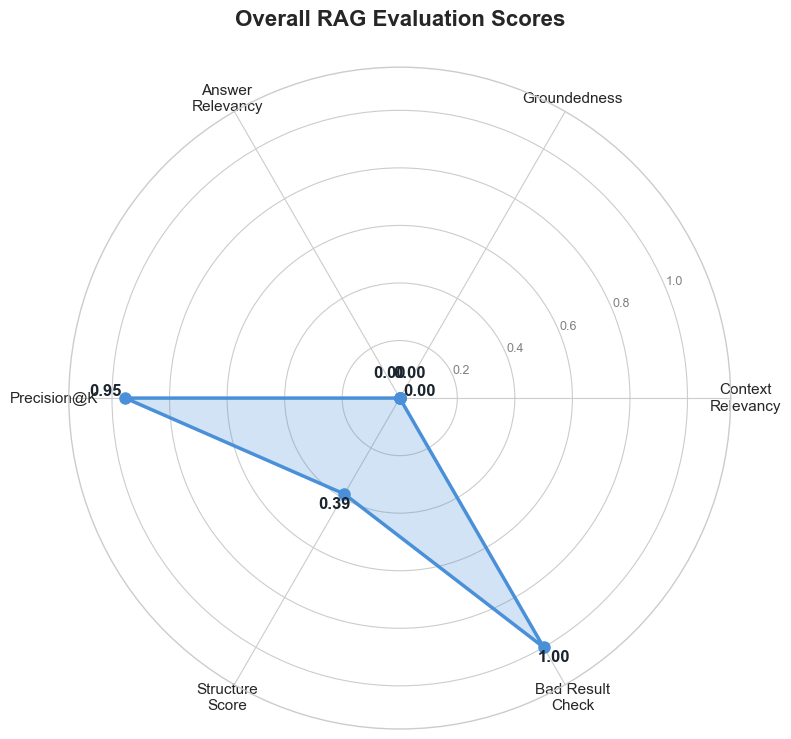

💾 Saved: radar_chart.png


In [80]:
# ── Radar chart of overall average scores ──
metrics = [
    ("Context\nRelevancy", summary.get("avg_context_relevancy", 0)),
    ("Groundedness", summary.get("avg_groundedness", 0)),
    ("Answer\nRelevancy", summary.get("avg_answer_relevancy", 0)),
    ("Precision@K", summary.get("avg_precision_at_k", 0)),
    ("Structure\nScore", summary.get("avg_structure_score", 0)),
    ("Bad Result\nCheck", summary.get("avg_bad_result_check", 0)),
]

labels = [m[0] for m in metrics]
values = [m[1] for m in metrics]
N = len(labels)

# Close the radar polygon
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
values_closed = values + [values[0]]
angles_closed = angles + [angles[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.fill(angles_closed, values_closed, color="#4A90D9", alpha=0.25)
ax.plot(angles_closed, values_closed, color="#4A90D9", linewidth=2.5, marker="o", markersize=8)

# Add score labels on each point
for angle, val, label in zip(angles, values, labels):
    ax.text(angle, val + 0.07, f"{val:.2f}", ha="center", va="bottom",
            fontsize=12, fontweight="bold", color="#1a252f")

ax.set_xticks(angles)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=9, color="gray")
ax.set_title("Overall RAG Evaluation Scores", fontsize=16, fontweight="bold", pad=30)

plt.tight_layout()
plt.savefig(results_dir / "radar_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved: radar_chart.png")

## 2. Per-Query Heatmap

Every query scored across all 6 metrics. Dark green = 1.0 (perfect), Red = 0.0 (failed).

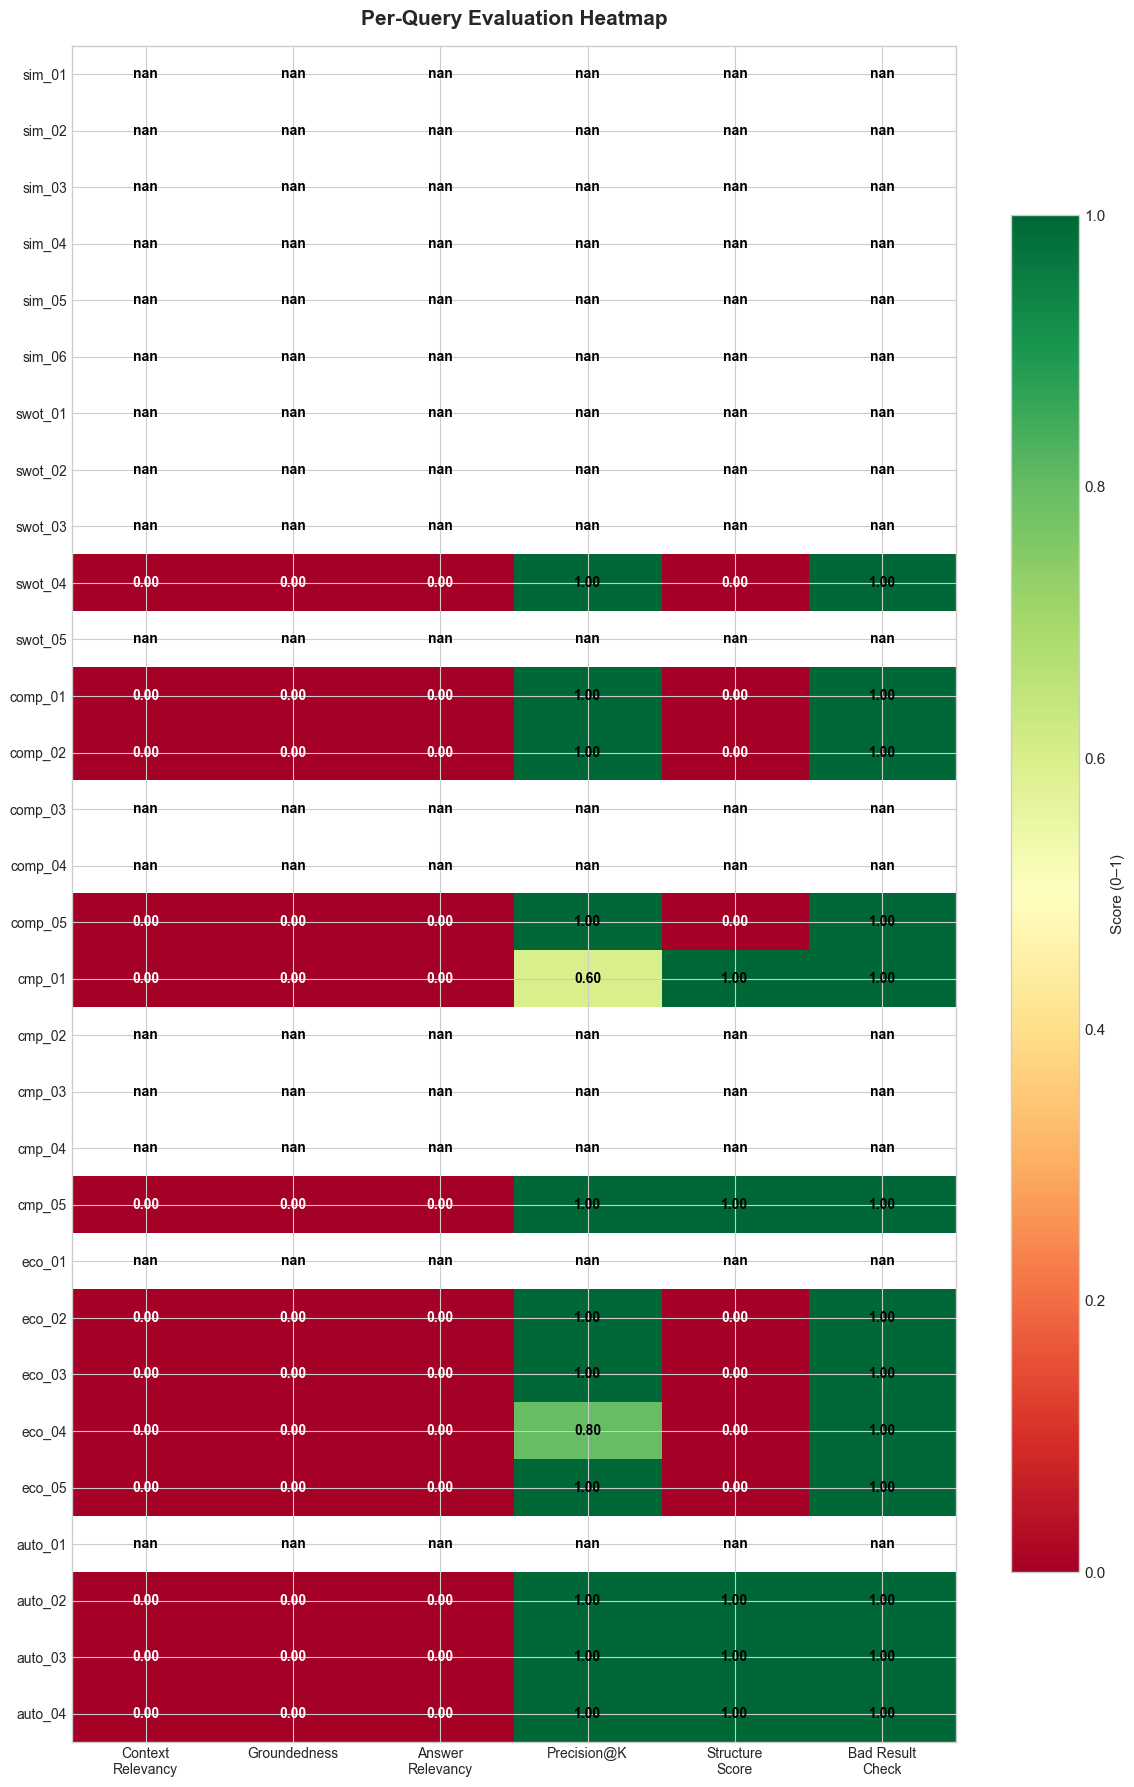

💾 Saved: heatmap.png


In [81]:
# ── Heatmap: every query × every metric ──
metric_cols = [
    "context_relevancy", "groundedness", "answer_relevancy",
    "precision_at_k", "structure_score", "bad_result_check",
]
metric_labels = [
    "Context\nRelevancy", "Groundedness", "Answer\nRelevancy",
    "Precision@K", "Structure\nScore", "Bad Result\nCheck",
]

heatmap_df = df[metric_cols].copy()
heatmap_df.index = df["id"]

fig, ax = plt.subplots(figsize=(12, max(4, len(df) * 0.6)))
im = ax.imshow(heatmap_df.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)

# Labels
ax.set_xticks(range(len(metric_labels)))
ax.set_xticklabels(metric_labels, fontsize=10, ha="center")
ax.set_yticks(range(len(heatmap_df)))
ax.set_yticklabels(heatmap_df.index, fontsize=10)

# Annotate each cell with the score
for i in range(len(heatmap_df)):
    for j in range(len(metric_cols)):
        val = heatmap_df.values[i, j]
        color = "white" if val < 0.4 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10,
                fontweight="bold", color=color)

ax.set_title("Per-Query Evaluation Heatmap", fontsize=15, fontweight="bold", pad=15)
plt.colorbar(im, ax=ax, label="Score (0–1)", shrink=0.8)
plt.tight_layout()
plt.savefig(results_dir / "heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved: heatmap.png")

## 3. Scores by Analysis Type

Average of the 3 core RAG metrics (Context Relevancy, Groundedness, Answer Relevancy) grouped by analysis type.

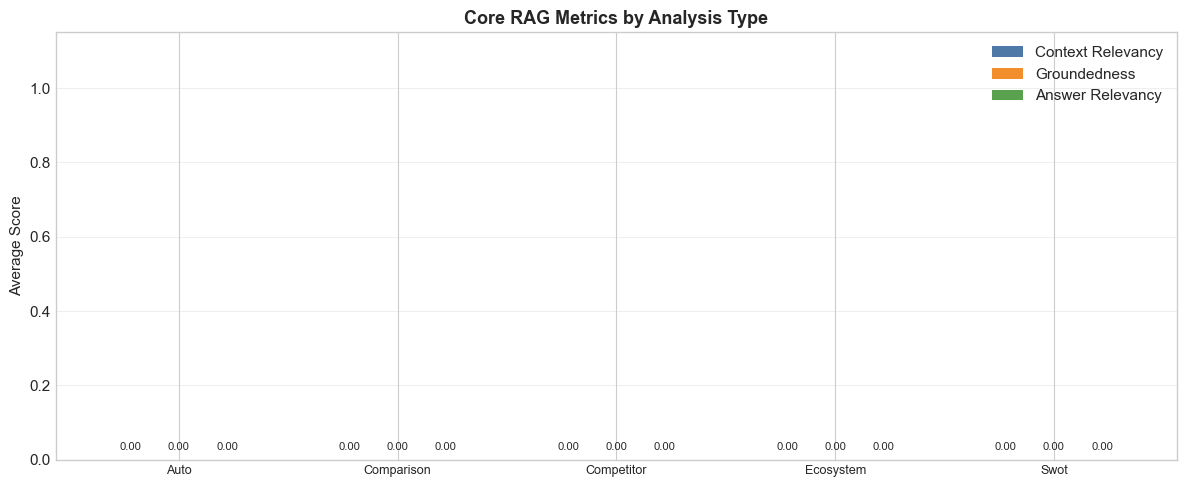

In [82]:
# ── Grouped bar chart: avg core metrics per analysis type ──
by_type = data["summary"]["by_analysis_type"]

types = sorted(by_type.keys())
core_metrics = ["context_relevancy", "groundedness", "answer_relevancy"]
labels = ["Context Relevancy", "Groundedness", "Answer Relevancy"]

x = np.arange(len(types))
width = 0.22

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#4e79a7", "#f28e2b", "#59a14f"]

for i, (metric, label, color) in enumerate(zip(core_metrics, labels, colors)):
    vals = [by_type[t].get(f"avg_{metric}", 0) for t in types]
    bars = ax.bar(x + i * width, vals, width, label=label, color=color)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{v:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels([t.replace("_", " ").title() for t in types], fontsize=9)
ax.set_ylabel("Average Score")
ax.set_ylim(0, 1.15)
ax.set_title("Core RAG Metrics by Analysis Type", fontsize=13, fontweight="bold")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / "scores_by_type.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Latency Distribution

Time taken (seconds) by the RAG chain for each query — highlights potential bottlenecks.

In [83]:
# ── Latency bar chart ──
latencies = [r["latency_seconds"] for r in results]
query_labels = [r["query"][:40] + "…" if len(r["query"]) > 40 else r["query"] for r in results]

fig, ax = plt.subplots(figsize=(10, max(4, len(results) * 0.45)))
bars = ax.barh(query_labels, latencies, color="#76b7b2", edgecolor="white")

for bar, val in zip(bars, latencies):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}s", va="center", fontsize=8)

ax.set_xlabel("Latency (seconds)")
ax.set_title("Per-Query Latency", fontsize=13, fontweight="bold")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / "latency_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n⏱  Avg latency: {np.mean(latencies):.1f}s  |  "
      f"Min: {np.min(latencies):.1f}s  |  Max: {np.max(latencies):.1f}s")

KeyError: 'latency_seconds'

## 5. Context Relevancy vs Answer Relevancy

Each dot is one query — colour = analysis type. Points on the diagonal mean retrieval quality matched generation quality.

In [ ]:
# ── Scatter: context relevancy vs answer relevancy ──
type_colors = {
    "similar": "#4e79a7",
    "swot": "#f28e2b",
    "competitor": "#e15759",
    "comparison": "#76b7b2",
    "ecosystem": "#59a14f",
    "auto": "#edc948",
}

fig, ax = plt.subplots(figsize=(7, 6))

for r in results:
    atype = r["analysis_type"]
    ax.scatter(
        r["context_relevancy"],
        r["answer_relevancy"],
        c=type_colors.get(atype, "#999"),
        s=120, edgecolors="white", linewidths=0.8, zorder=3,
    )

# diagonal reference
ax.plot([0, 1], [0, 1], ls="--", color="#aaa", lw=1, zorder=1)

# legend
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=c,
                  markersize=9, label=t.replace("_", " ").title())
           for t, c in type_colors.items() if any(r["analysis_type"] == t for r in results)]
ax.legend(handles=handles, loc="lower right", fontsize=8)

ax.set_xlabel("Context Relevancy")
ax.set_ylabel("Answer Relevancy")
ax.set_xlim(-0.05, 1.1)
ax.set_ylim(-0.05, 1.1)
ax.set_title("Retrieval vs Generation Quality", fontsize=13, fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / "scatter_relevancy.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Weakest Queries & Pass / Fail Summary

A query **passes** if all three core RAG metrics (Context Relevancy, Groundedness, Answer Relevancy) are ≥ **0.70**.  
The table below is sorted by the composite average (ascending) so the weakest queries appear first.

In [ ]:
# ── Pass / Fail summary table ──
THRESHOLD = 0.70
core = ["context_relevancy", "groundedness", "answer_relevancy"]

rows = []
for r in results:
    avg = np.mean([r[m] for m in core])
    passed = all(r[m] >= THRESHOLD for m in core)
    rows.append({
        "Query": r["query"][:55] + ("…" if len(r["query"]) > 55 else ""),
        "Type": r["analysis_type"].replace("_", " ").title(),
        "Ctx Rel": f"{r['context_relevancy']:.2f}",
        "Ground": f"{r['groundedness']:.2f}",
        "Ans Rel": f"{r['answer_relevancy']:.2f}",
        "Prec@K": f"{r['precision_at_k']:.2f}",
        "Struct": f"{r['structure_score']:.2f}",
        "BadChk": f"{r['bad_result_check']:.2f}",
        "Avg(core)": f"{avg:.2f}",
        "Pass?": "✅" if passed else "❌",
    })

summary_df = pd.DataFrame(rows).sort_values("Avg(core)")
display(summary_df.reset_index(drop=True).style.set_caption("Weakest → Strongest queries"))

# aggregate
n_pass = sum(1 for r in rows if r["Pass?"] == "✅")
n_total = len(rows)
print(f"\n{'='*50}")
print(f"  PASS RATE: {n_pass}/{n_total}  ({n_pass/n_total*100:.0f}%)")
print(f"  Threshold: all 3 core metrics ≥ {THRESHOLD}")
print(f"{'='*50}")

---

### 📌 How to re-generate

```bash
# Run eval (full 30 queries)
uv run python -m bizintel.evaluation.run_eval

# Or limit to N queries
uv run python -m bizintel.evaluation.run_eval --limit 10
```

Then **re-run all cells above** — the notebook auto-picks the latest result file.